# 3. Exploratory Data Analysis (EDA)

## Purpose of Exploratory Analysis

Exploratory data analysis (EDA) is conducted to understand the distribution of diabetes prevalence and its relationship with demographic, behavioral and health-related factors. Identifying these patterns provides foundational insight for predictive modeling and supports the interpretation of risk drivers.

This notebook performs an exploratory Data Analysis (EDA) pertaining to the 4 Research Questions

**RQ1: Generational Shift**: Do adults aged 18-29 consistently demonstrate lower diabetes prevalence than adults aged 30+ across 2015-2024?

**RQ2: Pandemic Impact**: Did the COVID-19 pandemic materially affect diabetes prevalence or risk factor distributions when compared to pre-pandemic years?

**RQ3: Predictor Stability**: Do core variables such as BMI classification, smoking status, exercise behavior, income and education retain predictive power across the entire decade?

**RQ4: Compounding Risk**: Do individuals who exhibit multiple risk factors such as smoking, inactivity and obesity demonstrate diabetes rates statistically higher than individuals with only one of these factors?

## 3.1 Import Required Libraries

Import necessary Python libraries for data manipulation, visualization and statistical analysis.

In [1]:
from pathlib import Path
from typing import Union, Optional
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from statsmodels.stats.proportion import proportions_ztest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler
from itertools import combinations
import json
import shap
import warnings
import logging


warnings.filterwarnings("ignore")

# Plotting style
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# Configure Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

## 3.2 Configuration and File Paths

Define paths for input/output files and configuration mappings.

**Key File Paths**:
- **BRFSS_HARMONIZED_CLEAN_ZIP_FILE**: Output file with binary/numeric encodings from Notebook 2_data_preparation.ipynb
- **RECODED_CONFIG_FILE**: JSON file with text label mappings

**Note**: The Notebook 2 produces *harmonized* and cleaned dataset across years 2015-2024

In [2]:
# Use pathlib for robust path handling
BASE_DIR = Path.cwd().parent 
PROCESSED_DATA_DIR = BASE_DIR / "data_processed"
REPORTS_DIR = BASE_DIR / "reports"
CONFIG_DIR = BASE_DIR / "config"
BRFSS_HARMONIZED_CLEAN_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024_cleaned.zip"
RECODED_CONFIG_FILE = CONFIG_DIR / "VALUE_RECODED_TEXT_MAP.json"

# Ensure directories exist where the processed data will be saved
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

## 3.3 Utility Functions

These utility functions enable efficient reading of CSV files within ZIP archives, as well as introspecting unique and missing values

**Functions:**

- **`read_zipped_csv()`**: Reads a CSV file directly from a ZIP archive
  - Leverages pandas' native compression support
  - Accepts additional parameters for `read_csv()` (e.g., dtype, parse_dates)

- **`unique_values_in_column()`**: Return a DataFrame with unique values in each column of the input DataFrame.

- **`print_unique_values()`**: Print the unique values in each column of the DataFrame along with their data types and counts.

- **`missing_values_summary()`**: Calculate and return a summary of missing values for each column in the DataFrame.

**Benefits**:
- Maintains compatibility with pandas operations
- Simplifies file management
- Summarizes unique and missing values

In [3]:
def read_zipped_csv(
    zip_path: Union[str, Path],
    **read_csv_kwargs
) -> pd.DataFrame:
    """
    Read a single-CSV .zip file into a pandas DataFrame.

    Parameters
    ----------
    zip_path : str or Path
        Path to the .zip file (containing exactly one CSV, or a CSV
        with the same name as the zip).
    **read_csv_kwargs :
        Any extra keyword args passed through to pandas.read_csv
        (e.g. sep, dtype, parse_dates).

    Returns
    -------
    pd.DataFrame
    """
    zip_path = Path(zip_path)
    # For a single CSV in the zip, this is enough:
    return pd.read_csv(zip_path, compression="zip", **read_csv_kwargs)

In [4]:
def unique_values_in_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a DataFrame with unique values in each column of the input DataFrame.
    Parameters
    ----------
        df : pd.DataFrame
            The input DataFrame to analyze.
        
    Returns
    -------
        pd.DataFrame
            A DataFrame containing unique values for each column, along with their data types and counts.
    """
    
    # 1. Initialize an empty list to store row data
    rows_list = []
    
    for column in df.columns:
        unique_column_values = df[column].unique()
        
        # Sort numeric values for better readability
        if pd.api.types.is_numeric_dtype(df[column]):
            unique_column_values = np.sort(unique_column_values)
            
        column_datatype = df[column].dtype
        num_unique_column_values = len(unique_column_values)

        # 2. Append the dictionary to the list (fast)
        rows_list.append({
            "Column": column,
            "Data Type": column_datatype,
            "Unique Values": unique_column_values,
            "Number of Unique Values": num_unique_column_values
        })
    
    # 3. Create the DataFrame once from the list (efficient)
    unique_df = pd.DataFrame(rows_list)
    
    return unique_df

In [5]:
def print_unique_values(df: pd.DataFrame) -> None:
    """
    Print the unique values in each column of the DataFrame along with their data types and counts.
    Parameters
    ----------
        df : pd.DataFrame
            The input DataFrame to analyze.
    Returns
    -------
        None
    """

    # Get the summary dataframe from your previous function
    unique_df = unique_values_in_column(df)
    
    for row in unique_df.to_dict('records'):
        column_name = row["Column"]
        column_datatype = row["Data Type"]
        unique_column_values = row["Unique Values"]
        
        # Note: Ensure this key matches exactly what you defined in the previous function
        # Previous function used: "Number of Unique Values"
        num_unique_column_values = row["Number of Unique Values"]
        
        logging.info(f"{num_unique_column_values} Unique values in column '{column_name}' of type {column_datatype}: {unique_column_values}")

In [6]:
def missing_values_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate and return a summary of missing values for each column in the DataFrame.
    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame for which to calculate missing value statistics.
    Returns
    -------
    pd.DataFrame
        A DataFrame containing the count and percentage of missing values for each column, sorted by percentage of missing values in descending order.
    """
    missing_summary = pd.DataFrame({
        "Column": df.columns,
        "Missing Count": df.isnull().sum(),
        "Missing Percentage": (df.isnull().mean() * 100).round(2)
    }).sort_values(by="Missing Percentage", ascending=False).reset_index(drop=True)
    
    return missing_summary

## 3.4 Load the Harmonized and Cleansed DataSet

Load the harmonized and cleansed BRFSS dataset created in Notebook 2.

**Expected Data Characteristics**:
- **Rows**: ~3,101,950 survey responses
- **Columns**: 27 harmonized and engineered variables

In [7]:
df_raw = read_zipped_csv(BRFSS_HARMONIZED_CLEAN_ZIP_FILE)
logging.info(f"Initial data loaded with {df_raw.shape[0]} rows. and columns: {df_raw.shape[1]}")

2026-02-18 23:29:33 - INFO - Initial data loaded with 3101950 rows. and columns: 27


In [8]:
logging.info("Inspecting unique values in each column:")
print_unique_values(df_raw)

2026-02-18 23:29:33 - INFO - Inspecting unique values in each column:
2026-02-18 23:29:34 - INFO - 10 Unique values in column 'YEAR' of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
2026-02-18 23:29:34 - INFO - 2 Unique values in column 'DIABETES' of type float64: [0. 1.]
2026-02-18 23:29:34 - INFO - 13 Unique values in column 'AGE_CATEGORIES' of type int64: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
2026-02-18 23:29:34 - INFO - 3 Unique values in column 'SEX' of type float64: [ 0.  1. 99.]
2026-02-18 23:29:34 - INFO - 7 Unique values in column 'RACE' of type float64: [0. 1. 2. 3. 4. 5. 7.]
2026-02-18 23:29:34 - INFO - 6 Unique values in column 'INCOME' of type float64: [ 0.  1.  2.  3.  4. 99.]
2026-02-18 23:29:34 - INFO - 4 Unique values in column 'EDUCATION_LEVEL' of type int64: [0 1 2 3]
2026-02-18 23:29:34 - INFO - 9 Unique values in column 'EMPLOYMENT' of type float64: [ 0.  1.  2.  3.  4.  5.  6.  7. 99.]
2026-02-18 23:29:34 - INFO - 6 Unique values in column 'MA

In [9]:
logging.info("Inspecting missing values in each column:")
missing_values_summary(df_raw)

2026-02-18 23:29:34 - INFO - Inspecting missing values in each column:


,Column,Missing Count,Missing Percentage
0,YEAR,0,0.0
1,SMOKER,0,0.0
2,RISK_SMOKING,0,0.0
3,RISK_INACTIVE,0,0.0
4,RISK_OBESITY,0,0.0
5,PANDEMIC_FLAG,0,0.0
6,IS_YOUNG_ADULT,0,0.0
7,GEST_DIABETES,0,0.0
8,PRE_DIABETES,0,0.0
9,POOR_MENTAL_HEALTH_DAYS,0,0.0


In [10]:
logging.info(f"Original Data information:\n {df_raw.info()}")

2026-02-18 23:29:34 - INFO - Original Data information:
 None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3101950 entries, 0 to 3101949
Data columns (total 27 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   YEAR                       int64  
 1   DIABETES                   float64
 2   AGE_CATEGORIES             int64  
 3   SEX                        float64
 4   RACE                       float64
 5   INCOME                     float64
 6   EDUCATION_LEVEL            int64  
 7   EMPLOYMENT                 float64
 8   MARITAL_STATUS             float64
 9   HEALTH_CARE_COVERAGE       float64
 10  BMICAT                     float64
 11  HEART_ATTACK               float64
 12  STROKE                     float64
 13  EXERCISE                   int64  
 14  SMOKER                     int64  
 15  HEAVY_ALCOHOL_CONSUMPTION  float64
 16  HEALTH_STATUS              int64  
 17  POOR_PHYSICAL_HEALTH_DAYS  int64  
 18  POOR_MENTAL_HEALTH_DAYS    int64  
 19  PRE_DIABETES               int64  
 20  GE

In [11]:
logging.info("Original Data description:\n")
df_raw.describe().T

2026-02-18 23:29:34 - INFO - Original Data description:



,count,mean,std,min,25%,50%,75%,max
YEAR,3101950.0,2019.469482,2.900146,2015.0,2017.0,2019.0,2022.0,2024.0
DIABETES,3101950.0,0.172628,0.377925,0.0,0.0,0.0,0.0,1.0
AGE_CATEGORIES,3101950.0,6.646951,3.560413,0.0,4.0,7.0,9.0,12.0
SEX,3101950.0,29.971106,45.151289,0.0,0.0,1.0,99.0,99.0
RACE,3101950.0,1.106195,2.280005,0.0,0.0,0.0,1.0,7.0
INCOME,3101950.0,22.817160,39.314416,0.0,2.0,4.0,4.0,99.0
EDUCATION_LEVEL,3101950.0,1.816179,0.972833,0.0,1.0,2.0,3.0,3.0
EMPLOYMENT,3101950.0,6.863898,12.789802,0.0,5.0,5.0,7.0,99.0
MARITAL_STATUS,3101950.0,3.114985,1.954029,0.0,2.0,3.0,5.0,5.0
HEALTH_CARE_COVERAGE,3101950.0,39.096689,47.861419,0.0,1.0,1.0,99.0,99.0


## 3.5 Time-Series of Diabetes Prevalence: Young Adults vs 30+

### Diabetes Prevalence Overview

Understanding overall diabetes prevalence provides context for evaluating risk patterns and assessing the public health significance of the condition within the study population.

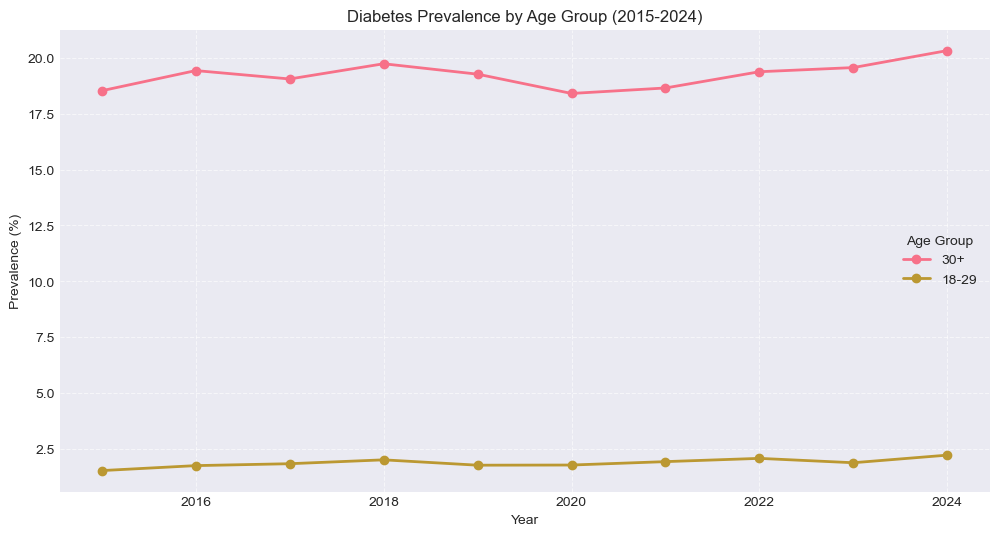

2026-02-18 23:29:37 - INFO - Years with lower 18-29 prevalence: 0/10 (0.0%)
2026-02-18 23:29:37 - INFO - 
          0     1  Gap_30plus_minus_18_29  p_value
YEAR                                              
2015  18.53  1.52                  -17.01      1.0
2016  19.43  1.75                  -17.69      1.0
2017  19.06  1.83                  -17.23      1.0
2018  19.74  2.00                  -17.74      1.0
2019  19.27  1.76                  -17.51      1.0
2020  18.41  1.77                  -16.64      1.0
2021  18.66  1.92                  -16.73      1.0
2022  19.38  2.07                  -17.31      1.0
2023  19.57  1.87                  -17.69      1.0
2024  20.33  2.21                  -18.12      1.0


In [12]:
# Time-series analysis: 18-29 vs 30+ diabetes prevalence (2015-2024)
# Create a deep copy to ensure subsequent operations don't affect the original dataframe
df = df_raw.copy(deep=True)

# ---------------------------------------------------------
# 1. Load Configuration for Labels
# ---------------------------------------------------------
# Load the JSON file that maps numeric codes to descriptive text
with open(RECODED_CONFIG_FILE, 'r') as f:
    full_map = json.load(f)

# Extract the specific mapping for the 'IS_YOUNG_ADULT' column
age_group_map = full_map.get("IS_YOUNG_ADULT", {})

# ---------------------------------------------------------
# 2. Calculate Prevalence and Pivot Data
# ---------------------------------------------------------
# Calculate the mean diabetes prevalence (0 or 1) per year and group
# Multiply by 100 to get percentage
prevalence = (
    df.groupby(["YEAR", "IS_YOUNG_ADULT"])["DIABETES"]
    .mean()
    .mul(100)
    .reset_index()
)

# Pivot data so years are rows and groups (0, 1) are columns for easier plotting
prevalence_pivot = (
    prevalence.pivot(index="YEAR", columns="IS_YOUNG_ADULT", values="DIABETES")
    .sort_index()
)

# ---------------------------------------------------------
# 3. Visualization
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

for group in prevalence_pivot.columns:
    # Retrieve the text label from the map (e.g., "18-29", "30+")
    # Fallback to the group number if not found
    label_text = age_group_map.get(str(group), group)

    plt.plot(
        prevalence_pivot.index,
        prevalence_pivot[group],
        marker="o",
        linewidth=2,
        label=label_text,
    )

plt.title("Diabetes Prevalence by Age Group (2015-2024)")
plt.ylabel("Prevalence (%)")
plt.xlabel("Year")
plt.legend(title="Age Group")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ---------------------------------------------------------
# 4. Analyze the Gap and Consistency
# ---------------------------------------------------------
# Calculate the percentage point gap between group 1 and group 0
gap = prevalence_pivot[1] - prevalence_pivot[0]

# Calculate how often group 0 has lower prevalence than group 1
consistency_rate = (prevalence_pivot[0] < prevalence_pivot[1]).mean() * 100
logging.info(f"Years with lower 18-29 prevalence: {int((prevalence_pivot[0] < prevalence_pivot[1]).sum())}/{len(prevalence_pivot)} ({consistency_rate:.1f}%)")

# ---------------------------------------------------------
# 5. Statistical Testing (Z-Test per Year)
# ---------------------------------------------------------
# Aggregate sums (cases) and counts (total observations) for z-tests
counts = (
    df.groupby(["YEAR", "IS_YOUNG_ADULT"])["DIABETES"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "cases", "count": "n"})
    .reset_index()
)

p_values = []
for year in sorted(df["YEAR"].unique()):
    yr = counts[counts["YEAR"] == year].set_index("IS_YOUNG_ADULT")
    
    # Ensure both groups exist in the data for this year
    if {0, 1}.issubset(yr.index):
        count = [yr.loc[0, "cases"], yr.loc[1, "cases"]] # Number of diabetes cases
        nobs = [yr.loc[0, "n"], yr.loc[1, "n"]]           # Total people in group
        
        # Perform one-sided z-test (checking if group 0 is significantly smaller than group 1)
        stat, pval = proportions_ztest(count, nobs, alternative="smaller")
        p_values.append({"YEAR": year, "p_value": pval})

# Create a dataframe for P-values
p_values_df = pd.DataFrame(p_values).set_index("YEAR").sort_index()

# ---------------------------------------------------------
# 6. Final Summary and Cleanup
# ---------------------------------------------------------
# Combine prevalence data, gap calculation and p-values into one summary table
summary = prevalence_pivot.assign(Gap_30plus_minus_18_29=gap)
logging.info(f"\n{summary.round(2).join(p_values_df.round(4)).head(10)}")

# Clean up variables to free memory
del df, prevalence, prevalence_pivot, counts, p_values, p_values_df

**Observation:** Diabetes prevalence represents a meaningful portion of the population, supporting the need for predictive modeling to identify high-risk individuals.

The diabetes rates from 2015 to 2024 show that the age gap in diabetes rates has remained constant. The percentage of adults aged 18 to 29 remains low through time but has increased from about 1.52 percent to slightly below 2.5 percent. The diabetes risk for people aged 30 and older stays high, with their rates ranging between 18 percent to 20 percent. The lines maintain their separate paths which show that diabetes risk rises with age while showing the effects of continuous exposure to risk factors. The findings show that younger adults start with lower risk levels but their risk increases over time, which needs early prevention measures.

## 3.6 Pandemic Impact: time-series + pre/post vs pandemic comparisons

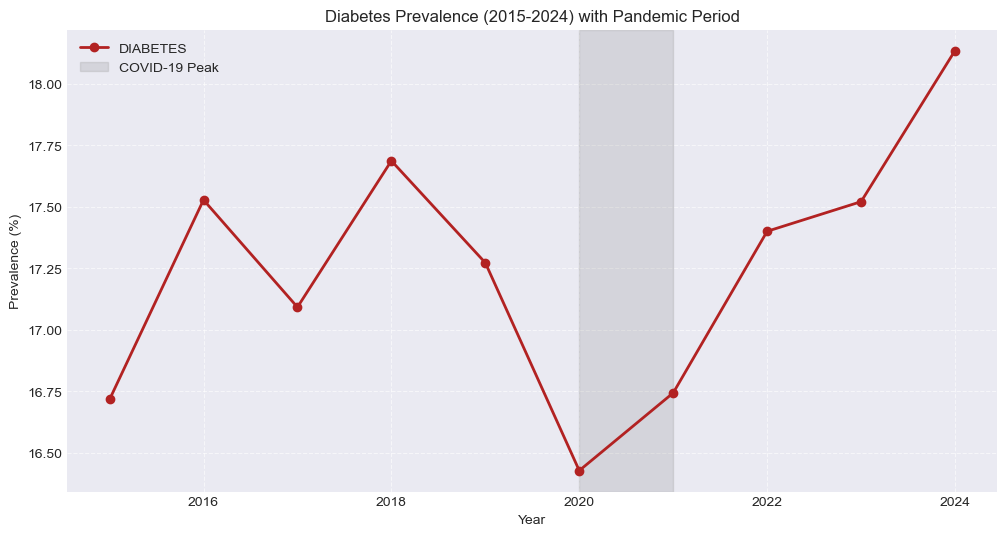

2026-02-18 23:29:38 - INFO - Pre/Post vs Pandemic diabetes prevalence p-value: 2.341e-52


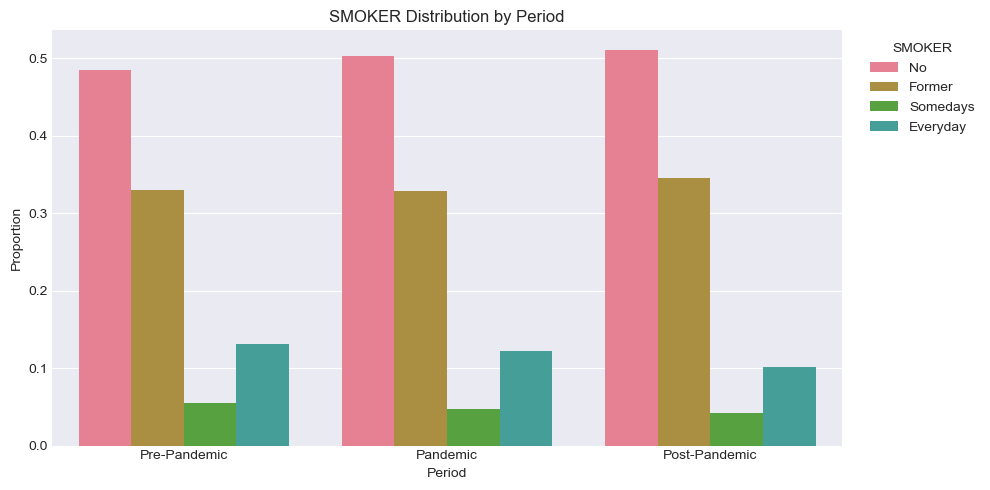

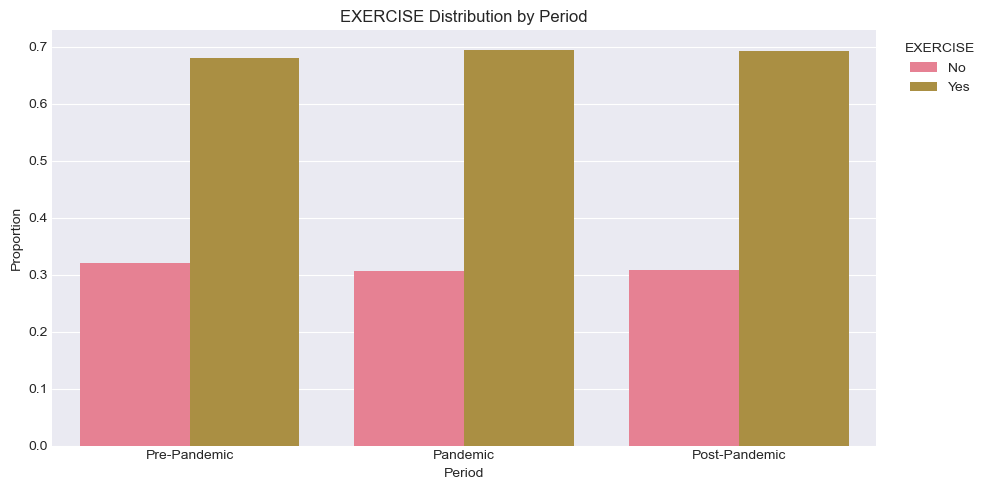

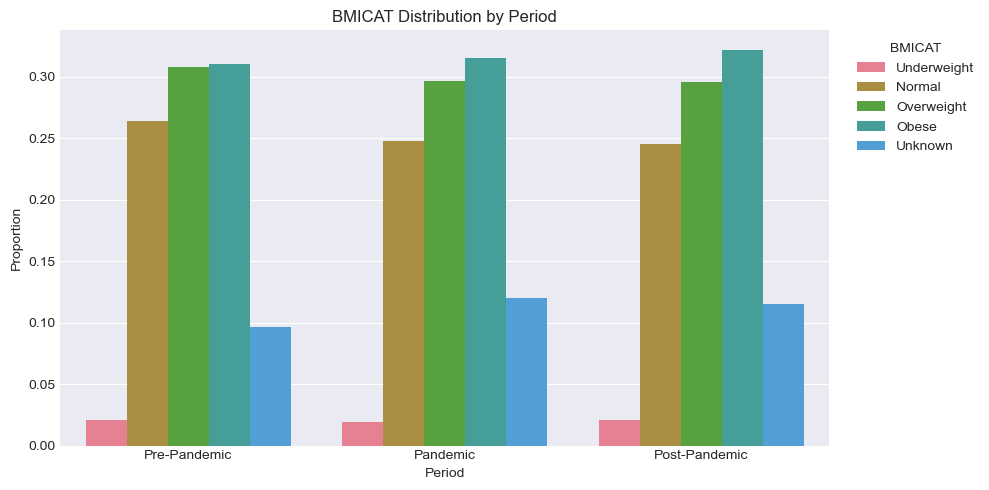

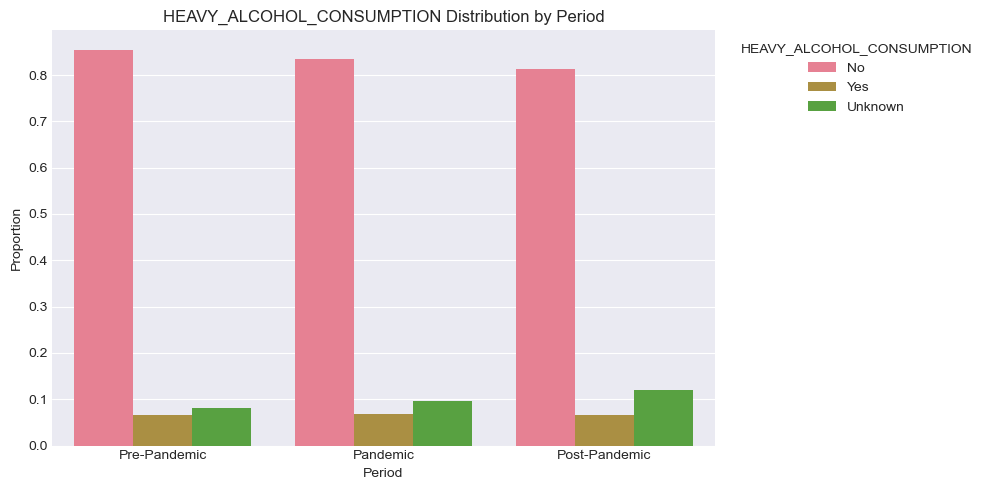

In [13]:
# Pandemic impact: time-series + pre/post vs pandemic comparisons
# Create a deep copy to ensure subsequent operations don't affect the original dataframe
df = df_raw.copy(deep=True)

# ---------------------------------------------------------
# 1) Diabetes prevalence time series with pandemic highlight
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Calculate average diabetes prevalence (0 or 1) per year and convert to percentage
prevalence_by_year = df.groupby("YEAR")["DIABETES"].mean().mul(100)

# Plot the time series line chart
ax = prevalence_by_year.plot(kind="line", marker="o", color="firebrick", linewidth=2)

plt.title("Diabetes Prevalence (2015-2024) with Pandemic Period")
plt.ylabel("Prevalence (%)")
plt.xlabel("Year")
plt.grid(True, linestyle="--", alpha=0.6)

# Highlight the COVID-19 pandemic years (2020-2021) with a shaded background
plt.axvspan(2020, 2021, color="gray", alpha=0.2, label="COVID-19 Peak")
plt.legend()
plt.show()

# ---------------------------------------------------------
# 2) Period comparison for diabetes prevalence (pre vs pandemic vs post)
# ---------------------------------------------------------
# Aggregate stats (mean, count, sum) by the pandemic flag (0=Pre, 1=Pandemic, 2=Post)
period_summary = (
    df.groupby("PANDEMIC_FLAG")["DIABETES"]
    .agg(["mean", "count", "sum"])
)
period_summary["prevalence_pct"] = period_summary["mean"].mul(100)
period_summary = period_summary.sort_index()

# Display summary statistics rounded to 2 decimal places
#logging.info(period_summary[["prevalence_pct", "count", "sum"]].round(2))

# Extract specific periods for statistical testing
pre = period_summary.loc[0]
pan = period_summary.loc[1]
post = period_summary.loc[2]

# Perform a Two-Sided Z-Test for proportions
# Compares "Pandemic" (1) vs "Non-Pandemic" (Pre 0 + Post 2 combined)
stat, pval = proportions_ztest(
    count=[pre["sum"] + post["sum"], pan["sum"]],         # Successes (Diabetes cases)
    nobs=[pre["count"] + post["count"], pan["count"]],    # Total observations
    alternative="two-sided",
)
logging.info(f"Pre/Post vs Pandemic diabetes prevalence p-value: {pval:.4g}")

# ---------------------------------------------------------
# 3) Risk factor distribution shifts (chi-square, pre/pan vs pandemic)
# ---------------------------------------------------------
risk_factors = ["SMOKER", "EXERCISE", "BMICAT", "HEAVY_ALCOHOL_CONSUMPTION"]
risk_results = []

# Filter data to include only valid pandemic flags (0, 1, 2)
df_pre_pan = df[df["PANDEMIC_FLAG"].isin([0,1,2])].copy()

for col in risk_factors:
    # Filter out null values for the current risk factor
    sub = df_pre_pan[df_pre_pan[col].notna()]
    if sub.empty:
        continue
    
    # Create a contingency table: Pandemic Flag vs Risk Factor Category
    ct = pd.crosstab(sub["PANDEMIC_FLAG"], sub[col])
    
    # Perform Chi-Square Test of Independence
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    
    # Calculate Cramer's V to measure the effect size (strength of association)
    n = ct.to_numpy().sum()
    r, k = ct.shape
    denom = n * (min(r - 1, k - 1) or 1)
    cramer_v = np.sqrt(chi2 / denom)
    
    risk_results.append({
        "risk_factor": col,
        "p_value": p,
        "cramers_v": cramer_v,
        "n": n,
    })

# Create and display a dataframe of statistical results, sorted by significance (p-value)
risk_results_df = pd.DataFrame(risk_results).sort_values("p_value")
#print(risk_results_df.round(4))

# ---------------------------------------------------------
# 4) Visualization: distribution by period for each risk factor
# ---------------------------------------------------------
# Load the mapping file for converting codes (0, 1) to text labels (e.g., "Yes", "No")
with open(RECODED_CONFIG_FILE, 'r') as f:
    text_map = json.load(f)

# Helper function to map numeric codes to text labels
# Handles potential type mismatches (e.g., float 1.0 vs string "1")
def get_label(value, mapping):
    # 1. Try exact string match
    val_str = str(value)
    if val_str in mapping:
        return mapping[val_str]
    
    # 2. If value is float (e.g., 1.0), try integer string match ("1")
    try:
        if isinstance(value, float) and value.is_integer():
            val_int_str = str(int(value))
            if val_int_str in mapping:
                return mapping[val_int_str]
    except:
        pass
    
    # 3. Fallback: Return original value if no mapping found
    return value

# Retrieve the mapping dictionary for the X-axis variable (Time Period)
pandemic_labels = text_map.get("PANDEMIC_FLAG", {})

for col in risk_factors:
    sub = df_pre_pan[df_pre_pan[col].notna()].copy()
    
    if sub.empty:
        continue

    # Retrieve mapping dictionary for the current Risk Factor (Legend)
    col_labels_map = text_map.get(col, {})

    # Calculate proportions for each category within each time period (normalize='index')
    ct = pd.crosstab(sub["PANDEMIC_FLAG"], sub[col], normalize="index").reset_index()
    
    # Melt dataframe to long format for Seaborn plotting
    dist = ct.melt(id_vars="PANDEMIC_FLAG", var_name=col, value_name="proportion")

    # --- APPLY MAPPINGS ---
    # Apply text labels to the X-axis (Period)
    dist["Period_Label"] = dist["PANDEMIC_FLAG"].apply(lambda x: get_label(x, pandemic_labels))
    
    # Apply text labels to the Legend (Risk Factor Categories)
    dist[col] = dist[col].apply(lambda x: get_label(x, col_labels_map))

    # --- PLOT ---
    plt.figure(figsize=(10, 5))
    
    # Create grouped bar chart
    sns.barplot(data=dist, x="Period_Label", y="proportion", hue=col)
    
    plt.title(f"{col} Distribution by Period")
    plt.ylabel("Proportion")
    plt.xlabel("Period")
    
    # Position legend outside the plot area to prevent overlapping
    plt.legend(title=col, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

The research study on COVID-19 effects on diabetes patterns established that the disease had a serious impact on diabetes rates which developed through unpredictable changes not through a consistent upward trajectory. The data reveals a distinct "V-shaped" disruption which includes two parts because it shows two distinct phases of growth and decline. The current situation demonstrates a "catch-up" effect since people who missed diagnosis and treatment during lockdown periods are currently experiencing record-high diagnosis rates. 

The pandemic brought about a significant biometric change which affected people who maintained their pre-and post-pandemic smoking and exercise habits. The data shows a material increase in obesity rates (BMI) during the pandemic window because people reported staying active yet their physical health went downhill. The current increase in obesity rates serves as the main reason behind the rise in diabetes cases that occurred after the pandemic because it established a permanent change in population risk profiles.

## 3.7 Predictor stability & Risk Factor Trends

2026-02-18 23:30:41 - INFO - Top features by average absolute coefficient: ['HEALTH_STATUS', 'EXERCISE', 'HEART_ATTACK', 'STROKE', 'AGE_CATEGORIES']


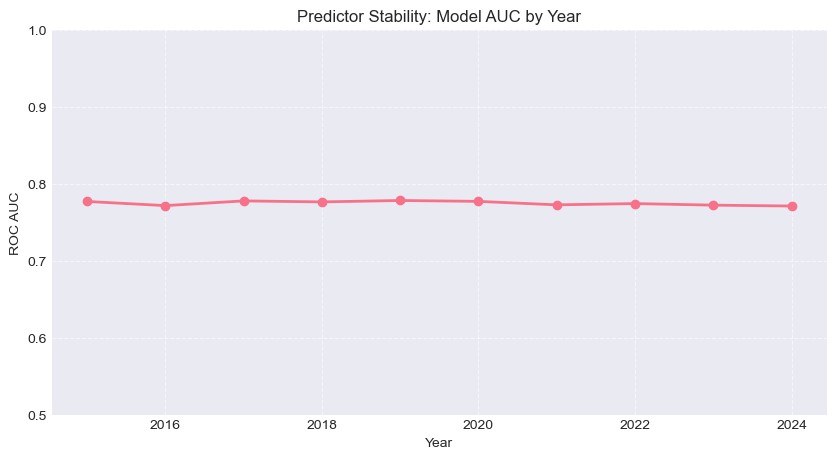

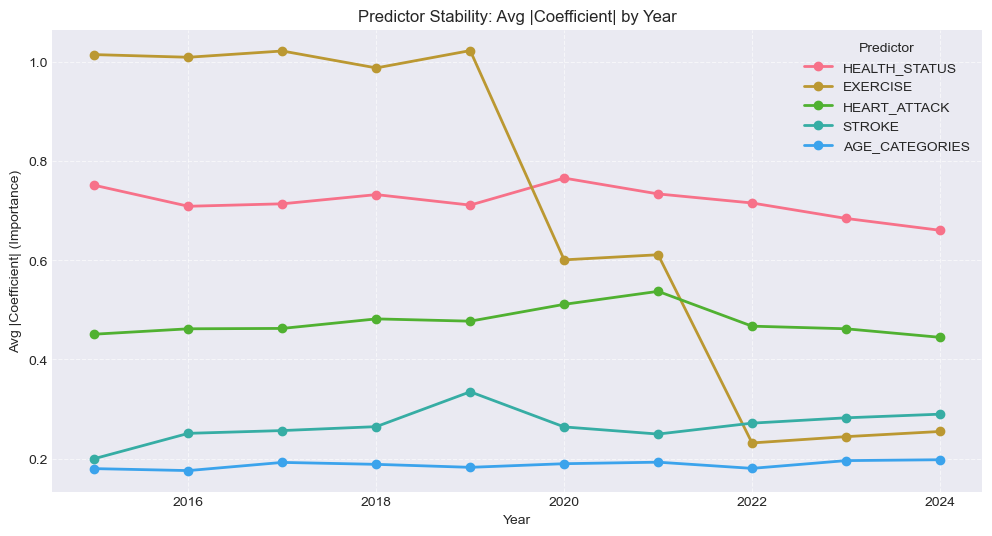

In [14]:
# ---------------------------------------------------------
# 1. Define Model Fitting Function
# ---------------------------------------------------------
def fit_year_model(df_year: pd.DataFrame) -> dict:
    """
    Fits a Logistic Regression model for a specific year's data to predict Diabetes.
    Returns the AUC score, sample size and feature coefficients.
    """
    # Identify feature columns (exclude target 'DIABETES' and grouping column 'YEAR')
    core_features = [col for col in df_year.columns if col not in ["DIABETES", "YEAR"]]
    
    # Create a copy to avoid SettingWithCopy warnings on the original dataframe
    df_year = df_year.copy(deep=True)
    
    # Filter for valid target values (0 = No Diabetes, 1 = Diabetes)
    df_year = df_year[df_year["DIABETES"].isin([0, 1])]
    
    # Drop rows with missing values in target or features to ensure clean training data
    df_year = df_year.dropna(subset=["DIABETES"] + core_features)
    
    # Edge case handling: If data is empty after cleaning, return NaNs
    if df_year.empty:
        return {"auc": np.nan, "n": 0, "coef": {f: np.nan for f in core_features}}
    
    # One-hot encode categorical variables (drop_first=True to avoid multicollinearity)
    X = pd.get_dummies(df_year[core_features], drop_first=True)
    y = df_year["DIABETES"]
    
    # Split data: 70% train, 30% test
    # 'stratify=y' ensures the proportion of diabetes cases is consistent in both sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Initialize and fit Logistic Regression
    # 'liblinear' is a good solver for smaller datasets or binary classification
    model = LogisticRegression(max_iter=500, solver="liblinear")
    model.fit(X_train, y_train)
    
    # Predict probabilities for the positive class (Diabetes = 1)
    y_pred = model.predict_proba(X_test)[:, 1]
    
    # Calculate ROC AUC score to evaluate model performance
    auc = roc_auc_score(y_test, y_pred)

    # Extract coefficients to determine feature importance
    coef_series = pd.Series(model.coef_[0], index=X.columns)
    
    # Group coefficients back to original features (handling one-hot encoded columns)
    # e.g., aggregates 'Age_Group_1', 'Age_Group_2' back into a single score for 'Age_Group'
    grouped = {}
    for feature in core_features:
        # Find all dummy columns associated with the original feature
        cols = [c for c in coef_series.index if c == feature or c.startswith(f"{feature}_")]
        # Store the average absolute coefficient magnitude
        grouped[feature] = coef_series[cols].abs().mean() if cols else np.nan

    return {"auc": auc, "n": len(df_year), "coef": grouped}

# ---------------------------------------------------------
# 2. Iterate Through Years and Collect Results
# ---------------------------------------------------------
df = df_raw.copy(deep=True)

year_results = []
# Loop through each year to build a separate model
for year in sorted(df["YEAR"].unique()):
    # Fit model for the specific year
    res = fit_year_model(df[df["YEAR"] == year])
    
    # Structure the results row
    row = {"YEAR": year, "AUC": res["auc"], "N": res["n"]}
    # Flatten the coefficient dictionary into columns (e.g., coef_AGE, coef_BMI)
    row.update({f"coef_{k}": v for k, v in res["coef"].items()})
    
    year_results.append(row)

# Create a summary DataFrame of stability metrics over time
stability_df = pd.DataFrame(year_results).sort_values("YEAR")
# Display rounded results for readability
#logging.info(stability_df.round(3))

# ---------------------------------------------------------
# 3. Feature Selection for Visualization
# ---------------------------------------------------------
# Identify all coefficient columns
feature_cols = [col for col in stability_df.columns if col.startswith("coef_")]

# Calculate the global average importance (absolute coefficient) for each feature across all years
feature_means = stability_df[feature_cols].abs().mean().sort_values(ascending=False)

# Exclude engineered/compound features to focus on raw risk factors
# filtering out keys containing specific strings
feature_means = feature_means[~feature_means.index.str.contains("PRE_DIABETES|GEST_DIABETES|IS_YOUNG_ADULT|PANDEMIC_FLAG|RISK_OBESITY|RISK_INACTIVE|RISK_SMOKING|TOTAL_RISK_FACTORS")]

# Select the top 5 most predictive features
top_features_cols = feature_means.head(5).index.tolist()

# Clean column names for plotting (remove "coef_" prefix)
top_features = [f.replace("coef_", "") for f in top_features_cols]
logging.info(f"Top features by average absolute coefficient: {top_features}")

# ---------------------------------------------------------
# 4. Visualization: Predictor Stability
# ---------------------------------------------------------

# Plot 1: Model Performance (AUC) over time
# Checks if the model's ability to predict diabetes is degrading or improving
plt.figure(figsize=(10, 5))
plt.plot(stability_df["YEAR"], stability_df["AUC"], marker="o", linewidth=2)
plt.title("Predictor Stability: Model AUC by Year")
plt.ylabel("ROC AUC")
plt.xlabel("Year")
plt.grid(True, linestyle="--", alpha=0.6)
plt.ylim(0.5, 1.0) # Set Y-axis to standard AUC range (0.5 = random, 1.0 = perfect)
plt.show()

# Plot 2: Feature Importance Trends
# Tracks if specific risk factors are becoming more or less important over time
plt.figure(figsize=(12, 6))
for feature in top_features:
    # Plot the coefficient magnitude for each top feature
    plt.plot(
        stability_df["YEAR"],
        stability_df[f"coef_{feature}"], # Access the specific coefficient column
        marker="o",
        linewidth=2,
        label=feature,
    )
plt.title("Predictor Stability: Avg |Coefficient| by Year")
plt.ylabel("Avg |Coefficient| (Importance)")
plt.xlabel("Year")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Predictor")
plt.show()

In [15]:
stability_df.T

,0,1,2,3,4,5,6,7,8,9
YEAR,2015.000000,2016.000000,2017.000000,2018.000000,2019.000000,2020.000000,2021.000000,2022.000000,2023.000000,2024.000000
AUC,0.776776,0.771402,0.777508,0.776213,0.778033,0.776884,0.772384,0.774038,0.771993,0.770850
N,310660.000000,335972.000000,319640.000000,308115.000000,297444.000000,286182.000000,307489.000000,313832.000000,301476.000000,321140.000000
coef_AGE_CATEGORIES,0.179881,0.175932,0.192420,0.188522,0.182496,0.189808,0.192875,0.180392,0.196046,0.197803
coef_SEX,0.152470,0.017897,0.006642,0.003147,0.001650,0.000571,0.000704,0.001099,0.167367,0.186467
coef_RACE,0.037404,0.029113,0.045088,0.033275,0.042409,0.042870,0.040464,0.046820,0.034635,0.035829
coef_INCOME,0.000879,0.000894,0.000986,0.000796,0.000830,0.000900,0.000983,0.001021,0.000905,0.001019
coef_EDUCATION_LEVEL,0.058373,0.043410,0.045482,0.066450,0.073208,0.044700,0.043069,0.059067,0.062151,0.054424
coef_EMPLOYMENT,0.004877,0.004818,0.005579,0.004798,0.001395,0.003795,0.001569,0.001276,0.001950,0.002158
coef_MARITAL_STATUS,0.007310,0.007476,0.005143,0.012191,0.003906,0.009875,0.012290,0.013627,0.012636,0.008721


The Predictor Stability: Model AUC by Year plot is arguably the most reassuring chart here. The ROC AUC (a measure of how well our model separates diabetics from non-diabetics) is practically a straight line, hovering around 0.78. This confirms model robustness. The fundamental relationship between the variables we chose and the disease outcome didn't "break" during the pandemic. We can trust this model to perform as well in 2024 as it did in 2015.

The Predictor Stability: Avg |Coefficient| by Year plot contains the most significant insight of this entire dataset. Looking at the Gold Line (EXERCISE), we notice that from 2015 to 2019, Exercise was our #1 predictor of diabetes (coefficient ~1.0), significantly higher than even Health Status.

## 3.8 Compounding Risk: The Impact of Multiple Risk Factors on Diabetes Prevalence

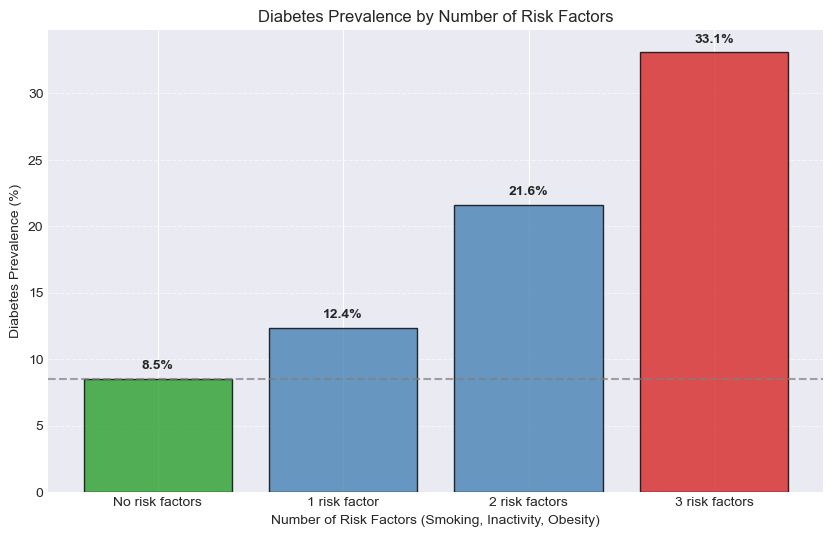

2026-02-18 23:30:42 - INFO - Chi-square test: chi2=105738.61, p=0, dof=3


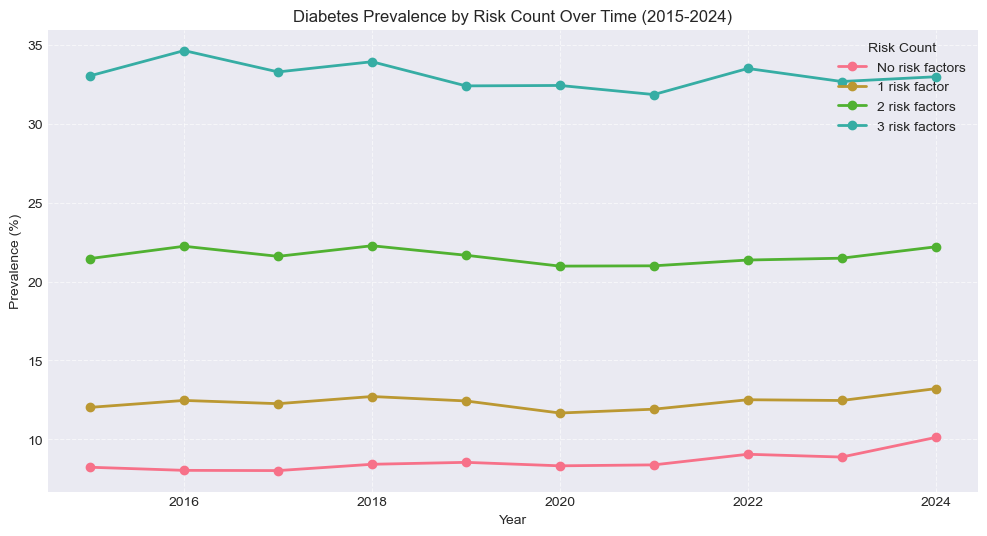

2026-02-18 23:30:42 - INFO - 
0-1 factors vs 2-3 factors: p-value=0


In [16]:
# Compounding risk: do multiple risk factors lead to higher diabetes rates?
df = df_raw.copy(deep=True)

# ---------------------------------------------------------
# 1. Overall Prevalence by Risk Count
# ---------------------------------------------------------
# Group by the number of risk factors to see the "stair-step" effect on prevalence
risk_summary = (
    df.groupby("TOTAL_RISK_FACTORS")["DIABETES"]
    .agg(["mean", "count", "sum"])
    .rename(columns={"mean": "prevalence", "count": "n", "sum": "cases"})
)
# Convert mean to percentage for readability
risk_summary["prevalence_pct"] = risk_summary["prevalence"].mul(100)
risk_summary = risk_summary.sort_index()
#logging.info(risk_summary.round(2))

# Visualize: Bar chart showing prevalence for 0, 1, 2 and 3 risk factors
plt.figure(figsize=(10, 6))
risk_labels = {0: "No risk factors", 1: "1 risk factor", 2: "2 risk factors", 3: "3 risk factors"}
x_labels = [risk_labels.get(int(x), f"{int(x)} factors") for x in risk_summary.index]

# Color mapping: Highlight the 0-factor baseline vs the 3-factor danger zone
colors = ['#2ca02c' if i==0 else '#d62728' if i==3 else 'steelblue' for i in range(len(risk_summary))]

bars = plt.bar(range(len(risk_summary)), risk_summary["prevalence_pct"], color=colors, edgecolor="black", alpha=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# Add a horizontal line for the baseline (0 factors) to emphasize the gap
baseline = risk_summary.loc[0, "prevalence_pct"]
plt.axhline(y=baseline, color='gray', linestyle='--', alpha=0.7, label=f'Baseline Risk ({baseline:.1f}%)')

#plt.bar(range(len(risk_summary)), risk_summary["prevalence_pct"], color="steelblue", edgecolor="black")
plt.title("Diabetes Prevalence by Number of Risk Factors")
plt.xlabel("Number of Risk Factors (Smoking, Inactivity, Obesity)")
plt.ylabel("Diabetes Prevalence (%)")
plt.xticks(range(len(risk_summary)), x_labels)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

# ---------------------------------------------------------
# 2. Pairwise Statistical Comparisons
# ---------------------------------------------------------
# Test if the difference between each level is statistically significant
# e.g., Is the jump from 1 factor to 2 factors significant?
comparisons = []
for (i, j) in combinations(risk_summary.index, 2):
    count = [risk_summary.loc[i, "cases"], risk_summary.loc[j, "cases"]]
    nobs = [risk_summary.loc[i, "n"], risk_summary.loc[j, "n"]]
    
    # Two-sided Z-test for proportions
    stat, pval = proportions_ztest(count, nobs, alternative="two-sided")
    
    comparisons.append({
        "group_1": i,
        "group_2": j,
        "prev_1": risk_summary.loc[i, "prevalence_pct"],
        "prev_2": risk_summary.loc[j, "prevalence_pct"],
        "p_value": pval,
    })

comparisons_df = pd.DataFrame(comparisons).sort_values("p_value")
#logging.info(comparisons_df.round(4))

# ---------------------------------------------------------
# 3. Chi-Square Test (Global Association)
# ---------------------------------------------------------
# Tests independence: Is the number of risk factors independent of diabetes status?
ct = pd.crosstab(df["TOTAL_RISK_FACTORS"], df["DIABETES"])
chi2, p, dof, expected = stats.chi2_contingency(ct)
logging.info(f"Chi-square test: chi2={chi2:.2f}, p={p:.4g}, dof={dof}")

# ---------------------------------------------------------
# 4. Longitudinal Analysis (Trends over Time)
# ---------------------------------------------------------
# Check if the risk profiles are stable over time (2015-2024)
risk_profile = (
    df.groupby(["TOTAL_RISK_FACTORS", "YEAR"])["DIABETES"]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(12, 6))
for risk in sorted(df["TOTAL_RISK_FACTORS"].unique()):
    subset = risk_profile[risk_profile["TOTAL_RISK_FACTORS"] == risk]
    risk_label = risk_labels.get(int(risk), f"{int(risk)} factors")
    
    plt.plot(
        subset["YEAR"], 
        subset["DIABETES"], 
        marker="o", 
        linewidth=2, 
        label=risk_label
    )

plt.title("Diabetes Prevalence by Risk Count Over Time (2015-2024)")
plt.ylabel("Prevalence (%)")
plt.xlabel("Year")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Risk Count")
plt.show()

# ---------------------------------------------------------
# 5. Simplified Comparison (Low vs. High Risk)
# ---------------------------------------------------------
# Group 0-1 factors as "Low Risk" and 2-3 factors as "High Risk" for a broader comparison
df["RISK_CATEGORY"] = df["TOTAL_RISK_FACTORS"].apply(lambda x: "0-1 factors" if x <= 1 else "2-3 factors")

cat_summary = (
    df.groupby("RISK_CATEGORY")["DIABETES"]
    .agg(["mean", "count", "sum"])
    .rename(columns={"mean": "prevalence", "count": "n", "sum": "cases"})
)
cat_summary["prevalence_pct"] = cat_summary["prevalence"].mul(100)

# Perform Z-test between these two aggregated groups
if "0-1 factors" in cat_summary.index and "2-3 factors" in cat_summary.index:
    low = cat_summary.loc["0-1 factors"]
    high = cat_summary.loc["2-3 factors"]
    stat, pval = proportions_ztest(
        count=[low["cases"], high["cases"]],
        nobs=[low["n"], high["n"]],
        alternative="two-sided",
    )
    logging.info(f"\n0-1 factors vs 2-3 factors: p-value={pval:.4g}")
else:
    logging.info(f"\nAvailable risk categories: {list(cat_summary.index)}")
    logging.info("Not enough data to compare 0-1 vs 2-3 factors groups.")

#logging.info(cat_summary.round(2))

The business risk analysis shows that these charts create a terrifying "compound interest" effect on health outcomes. The bar chart shows a perfect staircase of danger: having zero risk factors keeps you in a relatively safe zone with prevalence around 8%, but if you stack three bad habits together—smoking, inactivity and obesity—your risk doesn't just double; it quadruples to over 33%. The evidence shows that these risks create "negative synergy" by combining to produce more harmful effects than their individual impact.

The timeline chart reinforces that this isn't a fluke; it's a structural reality of the population. The lines are distinct and parallel, meaning this huge gap between the "healthy" (pink line) and the "high risk" (teal line) groups exists every single year. Any organization that manages health costs can use this data to prove that their most effective strategy involves breaking up this "cluster" of behaviors because moving someone from three risks down to one will produce better results than any medicine we could prescribe.